In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import normaltest, skew, kurtosis

In [2]:

df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
df

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11012,2010-07-10,57.0,300000.0,850.0,14756.0,48.0,Married,2.0,Own,620.0,...,Employed,Associate,38.0,167544.0,0.094756,0.106387,378.792448,0.039952,1.0,32.440586
11013,2003-10-22,28.0,15000.0,300.0,51361.0,96.0,Single,1.0,Own,696.0,...,Employed,Bachelor,5.0,116879.0,0.446361,0.401087,1793.042130,1.991234,0.0,67.673170
11014,1983-05-12,23.0,15000.0,302.0,30724.0,72.0,Married,3.0,Rent,413.0,...,Self-Employed,Associate,0.0,250778.0,0.404724,0.360670,1047.672294,1.168538,0.0,75.292707
11015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Получение общей информации о датасете: количество ненулевых значений, типы данных и объем памяти.

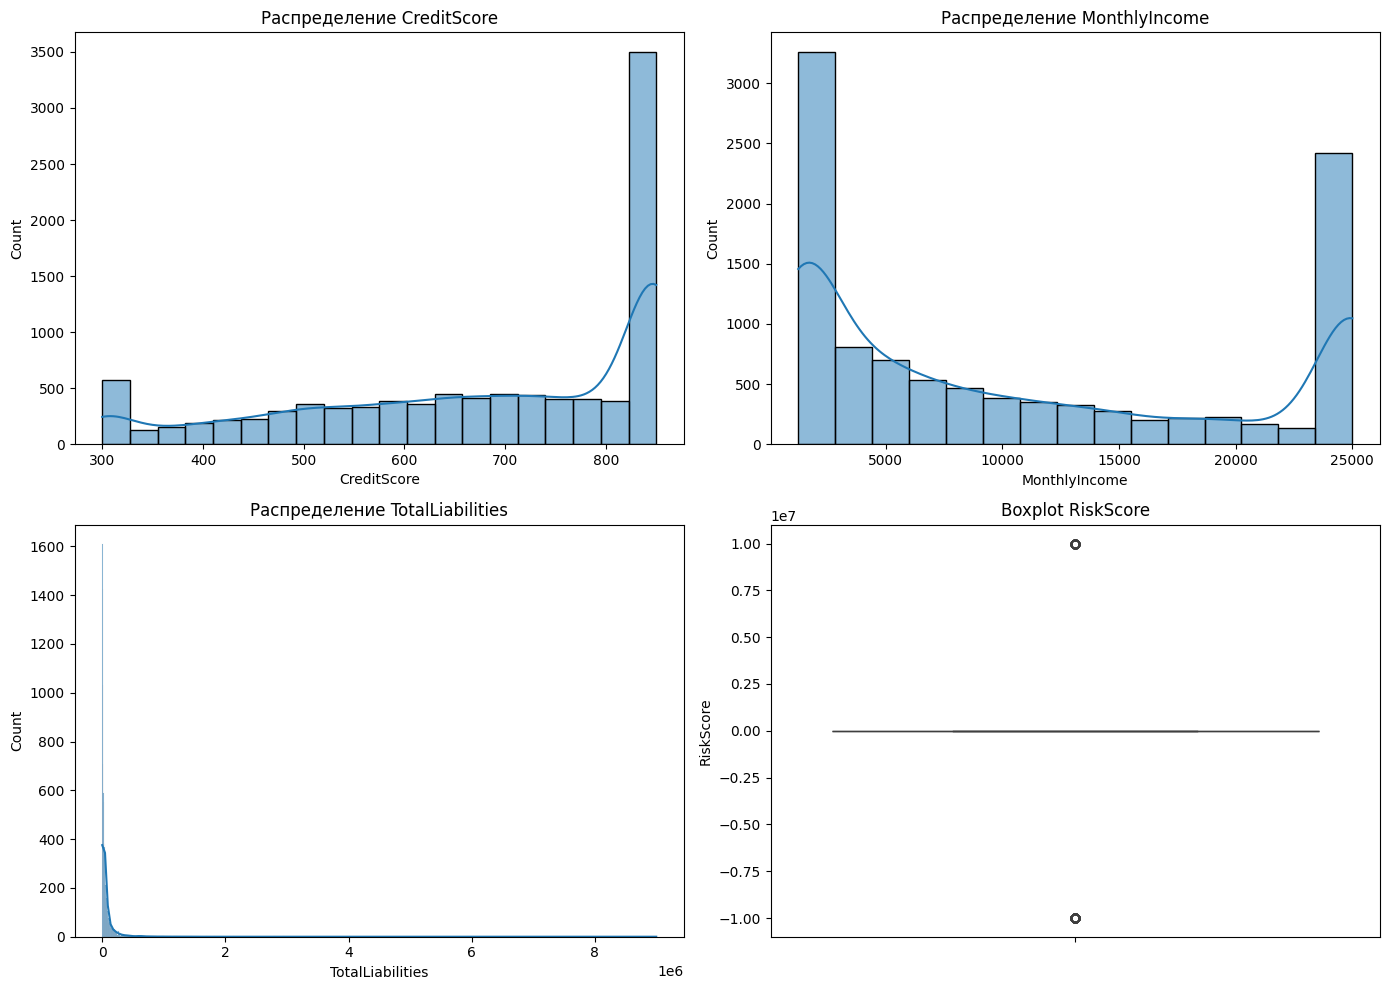

In [3]:

# ------------------------------
# Распределения признаков
# ------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['CreditScore'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Распределение CreditScore')

sns.histplot(df['MonthlyIncome'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Распределение MonthlyIncome')

sns.histplot(df['TotalLiabilities'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Распределение TotalLiabilities')

sns.boxplot(data=df, y='RiskScore', ax=axes[1, 1])
axes[1, 1].set_title('Boxplot RiskScore')

plt.tight_layout()
plt.show()



### Описание статистических характеристик числовых столбцов: среднее, стандартное отклонение, мин/макс, квартили.
 Проверка и базовая очистка

In [4]:

print(df.info())
print(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

Заполнение пропусков. Числовые значения меняем на медианные, категориальные - на числовые

In [5]:
df = df.dropna(subset=['RiskScore'], axis='rows').copy()
df['RiskScore'].isna().agg({'NA count': 'sum'})


for col in df.select_dtypes(include='number'):
    df[col] = df[col].fillna(df[col].median())

for col in test_df.select_dtypes(include='number'):
    test_df[col] = test_df[col].fillna(test_df[col].median())

for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = pd.factorize(df[col])[0]
    
for col in test_df.select_dtypes(include='object'):
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])
    test_df[col] = pd.factorize(test_df[col])[0]

for col in df.select_dtypes(include='datetime'):
    df[col] = (df[col] - pd.Timestamp("1970-01-01")).dt.total_seconds() / (24 * 3600)
    test_df[col] = (test_df[col] - pd.Timestamp("1970-01-01")).dt.total_seconds() / (24 * 3600)

pd.DataFrame({'NaN': df.isna().sum()})

,NaN
ApplicationDate,0
Age,0
AnnualIncome,0
CreditScore,0
LoanAmount,0
LoanDuration,0
MaritalStatus,0
NumberOfDependents,0
HomeOwnershipStatus,0
MonthlyDebtPayments,0


# Построение тепловой карты корреляции между признаками. Используется для анализа взаимосвязей между переменными.

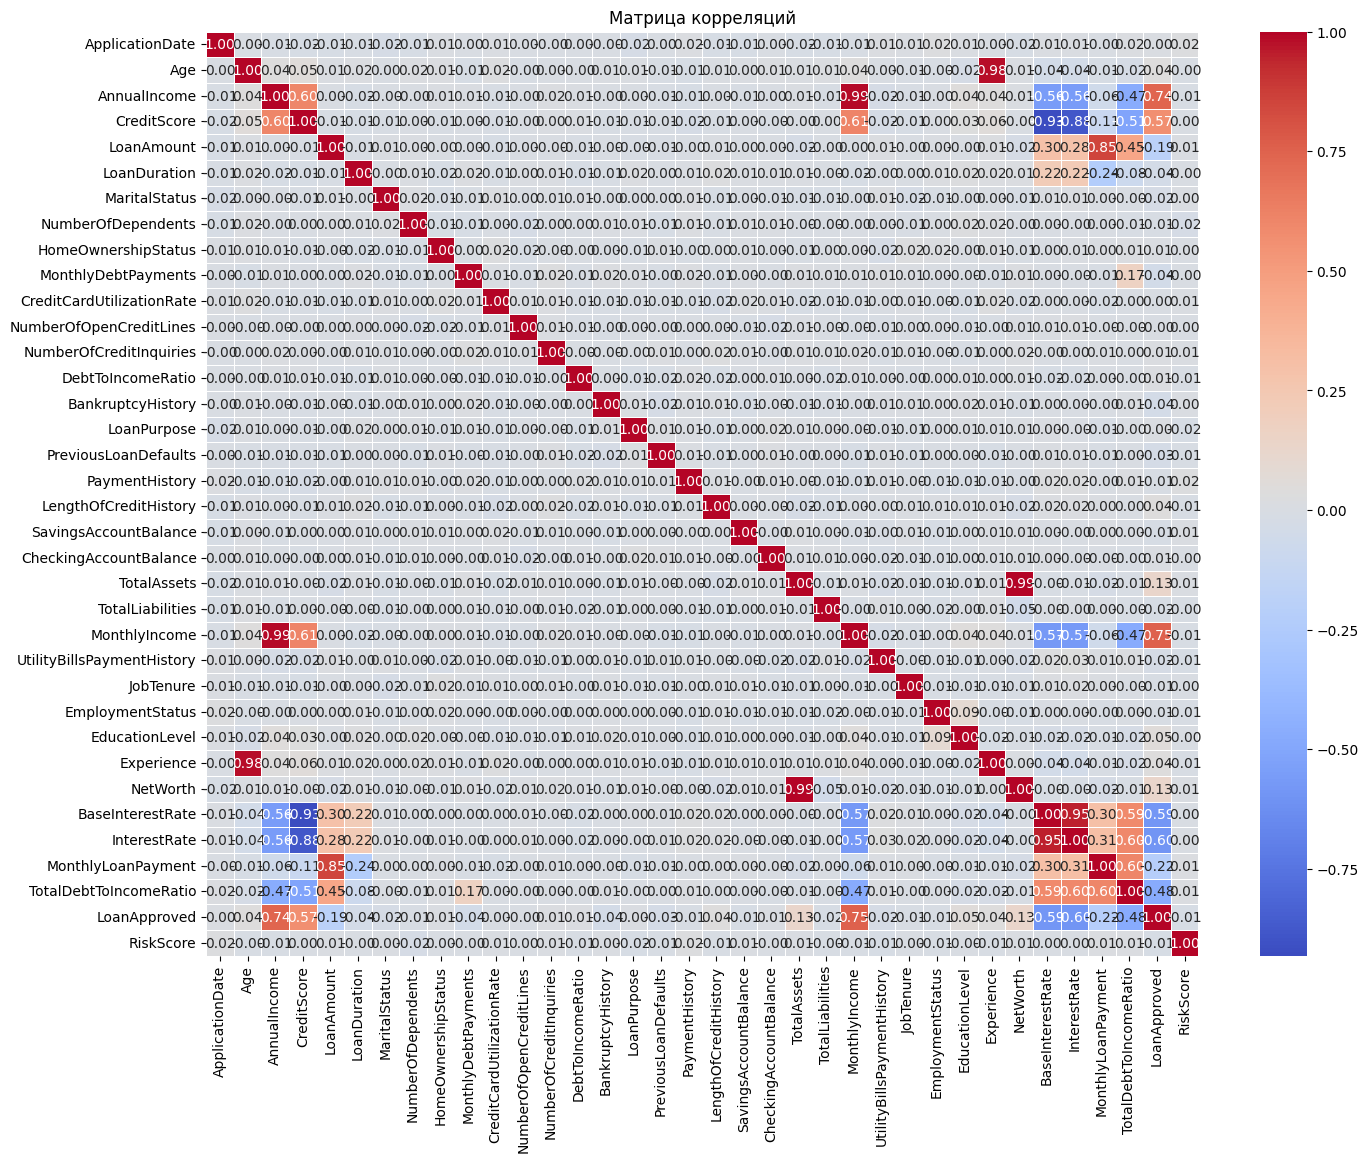

In [6]:
numeric_features = df.select_dtypes(include=np.number)
corr = numeric_features.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Матрица корреляций")
plt.show()

* Находим максимальную корреляцию для каждого признака
* Определяем признаки со слабой корреляцией (все значения ниже порога)
* Строим тепловую карту по отфильтрованным признакам

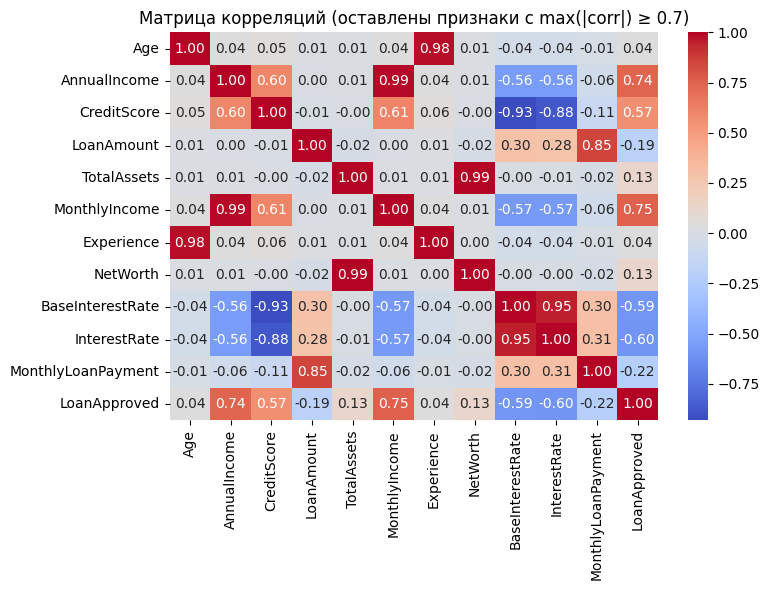

In [7]:
# Разделение признаков (X) и целевой переменной (y).
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

threshold = 0.7

cor_matrix = df.corr().abs()

np.fill_diagonal(cor_matrix.values, 0)


strongest_corr = cor_matrix.max(axis=0)


low_corr_features = strongest_corr[strongest_corr < threshold].index.tolist()


plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=low_corr_features).corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title(f'Матрица корреляций (оставлены признаки с max(|corr|) ≥ {threshold})')
plt.tight_layout()
plt.show()


Убираем все колонки выше заданного нами порога

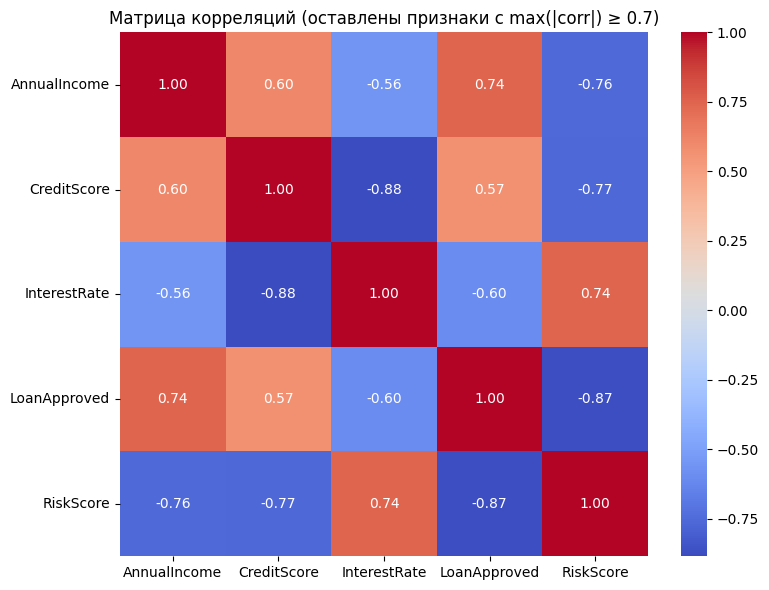

In [8]:
df = df.drop('MonthlyIncome', axis=1)
df = df.drop('BaseInterestRate', axis=1)
df = df.drop('NetWorth', axis=1)
df = df.drop('Experience', axis=1)
df = df.drop('MonthlyLoanPayment', axis=1)


test_df = test_df.drop('MonthlyIncome', axis=1)
test_df = test_df.drop('BaseInterestRate', axis=1)
test_df = test_df.drop('NetWorth', axis=1)
test_df = test_df.drop('Experience', axis=1)
test_df = test_df.drop('MonthlyLoanPayment', axis=1)

df = df[(df['RiskScore'] < 100) & (df['RiskScore'] > 0)]

threshold = 0.7

cor_matrix = df.corr().abs()

np.fill_diagonal(cor_matrix.values, 0)

strongest_corr = cor_matrix.max(axis=0)

low_corr_features = strongest_corr[strongest_corr < threshold].index.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=low_corr_features).corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title(f'Матрица корреляций (оставлены признаки с max(|corr|) ≥ {threshold})')
plt.tight_layout()
plt.show()

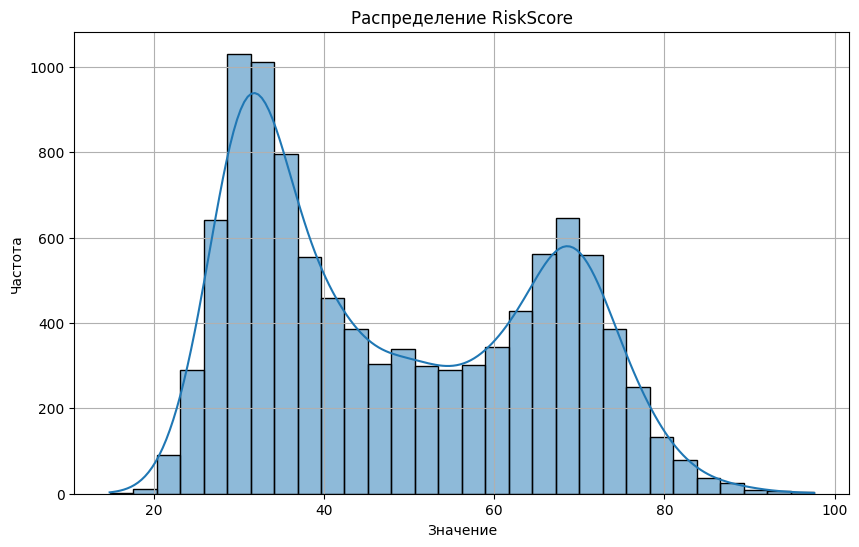

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='RiskScore', bins=30, kde=True)
plt.title('Распределение RiskScore')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

Проверяем какие признаки распределены нормально, а какие — нет. Важно для линейной регрессии

In [10]:
def check_normality(data: pd.DataFrame) -> pd.DataFrame:
    results = []

    for col in data.columns:
        x = data[col].values

        if len(x) > 8:
            _, p = normaltest(x)
            s = skew(x)
            k = kurtosis(x)

            results.append({
                'feature': col,
                'p_value': p,
                'skewness': s,
                'kurtosis': k,
                'sample_size': len(x)
            })

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('p_value', ascending=False)

    return df_results

features = df.drop(columns=['RiskScore'])
features = features.select_dtypes(include=np.number)
normality_results = check_normality(features)

print("Результаты проверки нормальности распределений:")
print(normality_results[['feature', 'p_value', 'skewness', 'kurtosis']])

Результаты проверки нормальности распределений:
                       feature        p_value   skewness    kurtosis
17              PaymentHistory   7.879397e-12   0.172462   -0.045915
1                          Age   7.381536e-29   0.170121   -0.355505
24                   JobTenure   8.185493e-73   0.446744    0.234546
26              EducationLevel  2.278932e-110   0.578385    0.140779
10   CreditCardUtilizationRate  6.966200e-115   0.587675   -0.168916
11     NumberOfOpenCreditLines  1.957693e-115   0.578543    0.305496
5                 LoanDuration  5.738168e-151   0.689213    0.237214
13           DebtToIncomeRatio  1.985855e-153   0.704175    0.127500
7           NumberOfDependents  8.071791e-157   0.714683   -0.099104
23  UtilityBillsPaymentHistory  6.062056e-174  -0.748216    0.283612
2                 AnnualIncome  8.761420e-176   0.669315   -0.470907
27                InterestRate  1.212841e-179   0.773373    0.165886
6                MaritalStatus  2.090843e-216  -0.86803

Логарифмируем сильно скошенные числовые признаки в train и test.
Заменяем исходные признаки логарифмическими.

In [11]:
def log_transform_skewed_features(train_df, test_df, target_col=None, skew_threshold=0.5):

    numeric_cols = train_df.select_dtypes(include=np.number).columns
    if target_col:
        numeric_cols = numeric_cols.drop(target_col, errors='ignore')

    for col in numeric_cols:
        if (train_df[col] >= 0).all() and skew(train_df[col]) > skew_threshold:
            new_col = col
            train_df[new_col] = np.log1p(train_df[col])
            test_df[new_col] = np.log1p(test_df[col])
    return train_df, test_df

df, test_df = log_transform_skewed_features(df, test_df, 'RiskScore')

features = df.drop(columns=['RiskScore'])
features = features.select_dtypes(include=np.number)
normality_results = check_normality(features)

print("Результаты проверки нормальности распределений:")
print(normality_results[['feature', 'p_value', 'skewness', 'kurtosis']])

Результаты проверки нормальности распределений:
                       feature        p_value  skewness   kurtosis
22            TotalLiabilities   8.422025e-01  0.009820   0.018809
19       SavingsAccountBalance   5.444285e-01  0.022352   0.027584
4                   LoanAmount   2.330450e-01  0.027401   0.061663
9          MonthlyDebtPayments   7.461801e-02 -0.018704   0.107105
20      CheckingAccountBalance   6.915733e-04 -0.044853   0.172712
17              PaymentHistory   7.879397e-12  0.172462  -0.045915
21                 TotalAssets   9.731169e-24  0.251691  -0.039330
1                          Age   7.381536e-29  0.170121  -0.355505
24                   JobTenure   8.185493e-73  0.446744   0.234546
13           DebtToIncomeRatio   1.274716e-85  0.448264  -0.347688
10   CreditCardUtilizationRate   1.659753e-92  0.333104  -0.539052
26              EducationLevel  1.010494e-123 -0.387144  -0.597041
27                InterestRate  2.713890e-132  0.608293  -0.321187
5             

Вывод метрик качества модели логистической регрессии: точность, матрица ошибок и отчет классификации.

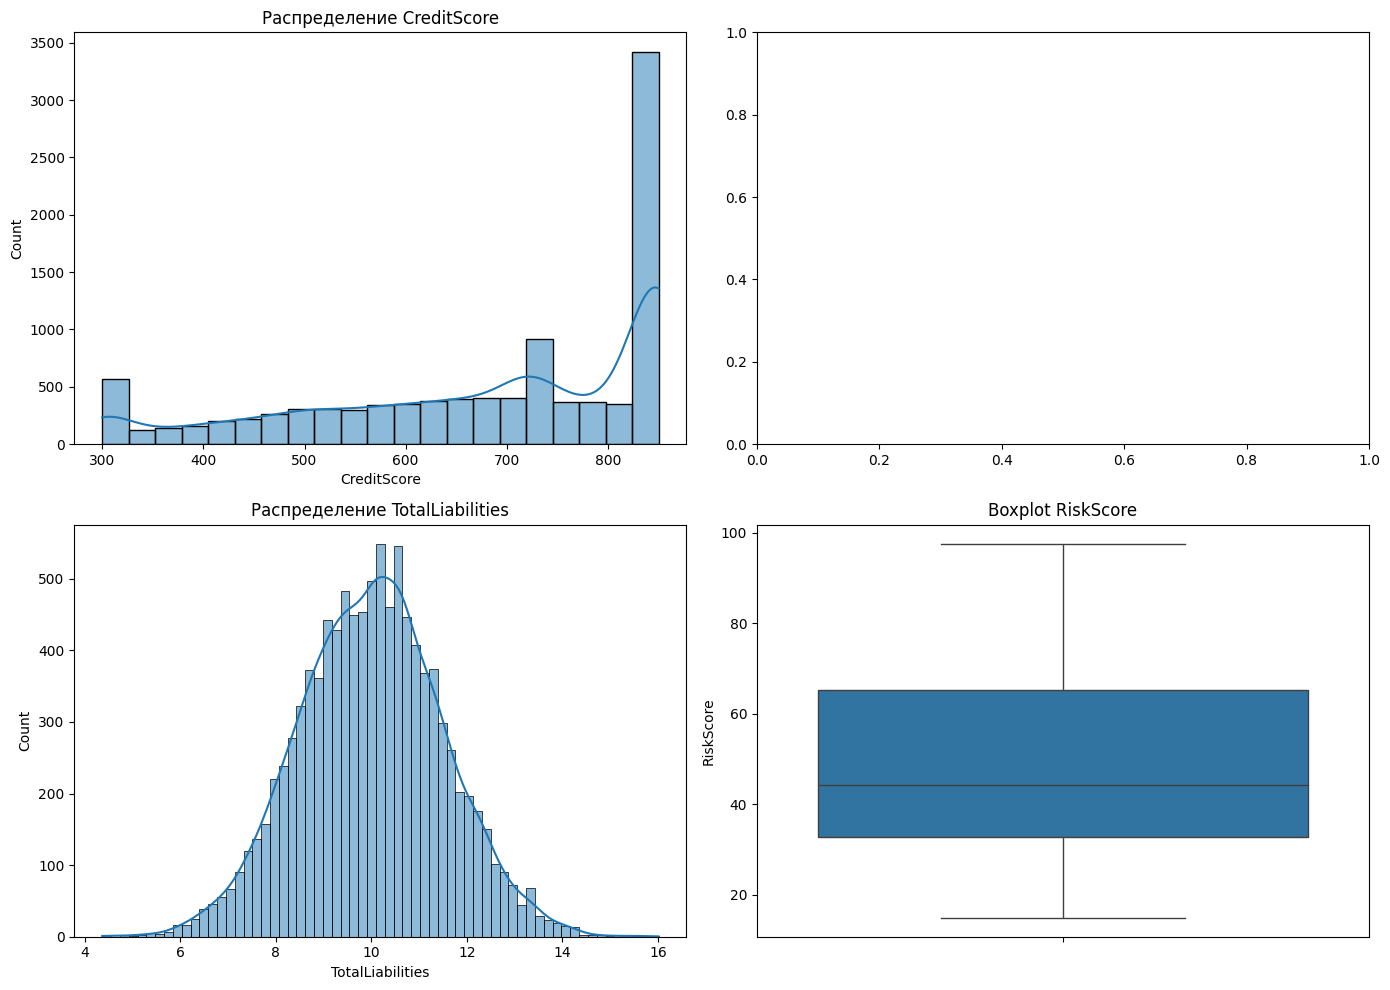

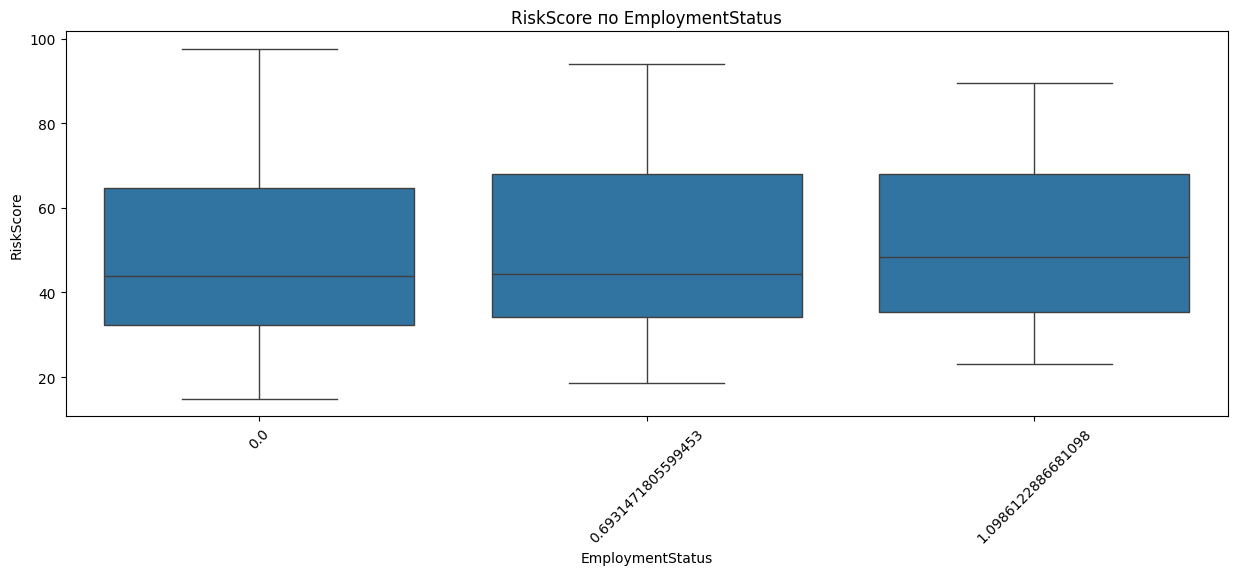

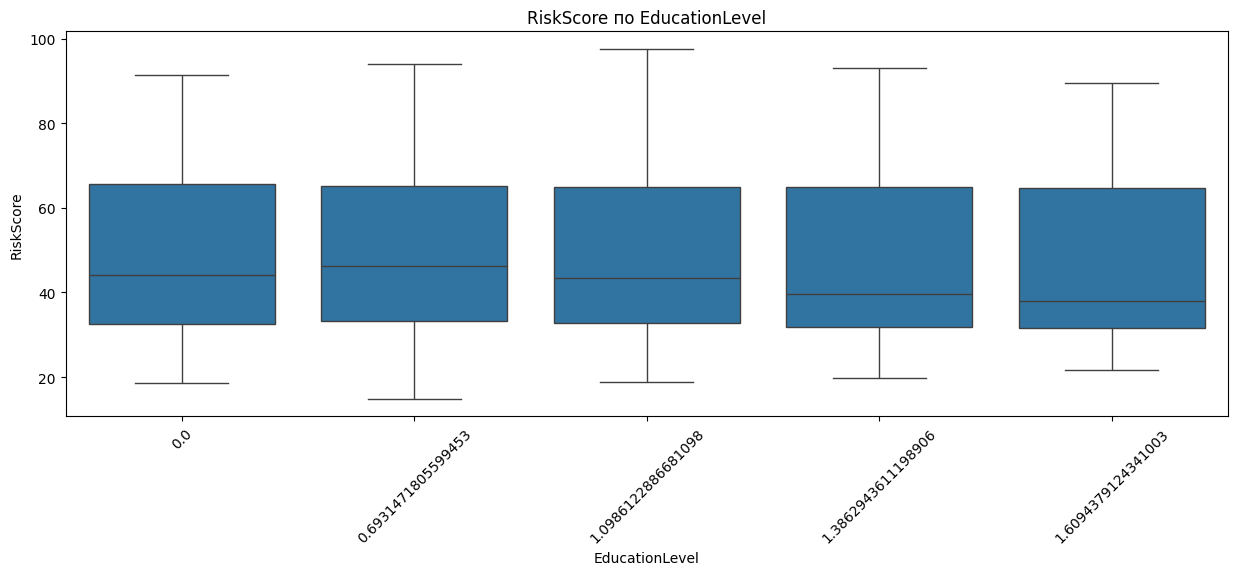

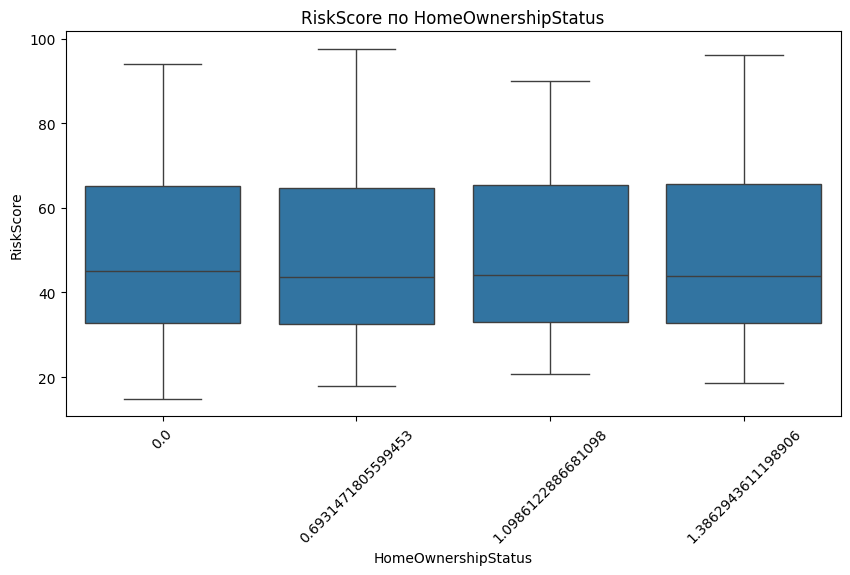

In [12]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['CreditScore'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Распределение CreditScore')

sns.histplot(df['TotalLiabilities'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Распределение TotalLiabilities')

sns.boxplot(data=df, y='RiskScore', ax=axes[1, 1])
axes[1, 1].set_title('Boxplot RiskScore')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
sns.boxplot(data=df, x='EmploymentStatus', y='RiskScore')
plt.title('RiskScore по EmploymentStatus')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(15, 5))
sns.boxplot(data=df, x='EducationLevel', y='RiskScore')
plt.title('RiskScore по EducationLevel')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='HomeOwnershipStatus', y='RiskScore')
plt.title('RiskScore по HomeOwnershipStatus')
plt.xticks(rotation=45)
plt.show()


Реализация Z-score и MinMax нормализаций

In [13]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

features = df.select_dtypes(include='number').drop(columns=['RiskScore'])

class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        """Вычисляет среднее и стандартное отклонение по каждому признаку"""
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        return self

    def transform(self, X):
        """Применяет ранее вычисленные параметры к новым данным"""
        if self.mean_ is None or self.std_ is None:
            raise RuntimeError("Сначала вызовите fit().")
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        """Выполняет fit() и сразу же transform()"""
        return self.fit(X).transform(X)

class MyMinMaxScaler:
    def __init__(self, feature_range=(0, 1)):
        self.min_ = None
        self.max_ = None
        self.scale_ = None
        self.data_min = feature_range[0]
        self.data_max = feature_range[1]

    def fit(self, X):
        """Сохраняет минимумы и максимумы по каждому признаку"""
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        scale_range = self.data_max - self.data_min
        data_range = self.max_ - self.min_
        # избежать деления на 0
        self.scale_ = np.where(data_range != 0, scale_range / data_range, 0)
        return self

    def transform(self, X):
        """Масштабирует данные с использованием сохранённых параметров"""
        if self.min_ is None or self.scale_ is None:
            raise RuntimeError("Сначала вызовите fit().")
        return self.data_min + (X - self.min_) * self.scale_

    def fit_transform(self, X):
        """Комбинация fit и transform"""
        return self.fit(X).transform(X)



zscore_scaler = MyStandardScaler()
X_zscore = zscore_scaler.fit_transform(features)

minmax_scaler = MyMinMaxScaler()
X_minmax = minmax_scaler.fit_transform(features)

features

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,CheckingAccountBalance,TotalAssets,TotalLiabilities,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,InterestRate,TotalDebtToIncomeRatio,LoanApproved
0,0,27.0,11.109907,549.0,9.757941,4.110874,0,0.693147,0.000000,6.999422,...,5.513429,10.821237,9.616205,0.908289,4.0,0.000000,0.000000,0.224315,0.253101,0.0
1,1,55.0,12.056110,850.0,9.687258,3.610918,1,0.693147,0.693147,5.356586,...,6.543912,11.428228,11.080264,0.797339,2.0,0.000000,0.693147,0.089084,0.049347,1.0
2,2,51.0,12.611541,850.0,10.556776,3.610918,2,0.000000,0.693147,6.304449,...,6.480045,12.585539,9.541010,0.915945,3.0,0.000000,1.098612,0.109252,0.070059,1.0
3,3,25.0,10.454034,847.0,9.861988,3.891820,2,0.000000,1.098612,5.036953,...,6.272877,9.478151,8.255049,0.876416,3.0,0.000000,0.693147,0.106899,0.203279,1.0
4,4,55.0,12.611541,850.0,10.323447,3.891820,3,1.098612,0.000000,6.333280,...,4.859812,10.415053,12.770261,0.888689,5.0,0.000000,1.098612,0.085294,0.051379,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11011,333,39.0,12.611541,850.0,8.951829,4.290459,0,1.791759,1.386294,5.624018,...,6.545350,11.071066,10.729350,0.877998,2.0,0.000000,0.000000,0.103094,0.016755,1.0
11012,472,57.0,12.611541,850.0,9.599473,3.891820,2,1.098612,1.386294,6.431331,...,6.683361,12.033064,6.525030,0.786244,4.0,0.000000,0.000000,0.101099,0.039174,1.0
11013,7830,28.0,9.615872,300.0,10.846654,4.574711,3,0.693147,1.386294,6.546785,...,8.255049,11.683748,7.466799,0.738173,3.0,0.000000,1.098612,0.337248,1.095686,0.0
11014,4257,23.0,9.615872,302.0,10.332832,4.290459,2,1.386294,0.000000,6.025866,...,7.353082,12.446679,8.195885,0.761952,3.0,0.693147,0.000000,0.307977,0.774053,0.0


Реализация собственной модели линейной регрессии с тремя методами обучения

In [14]:
import numpy as np

class MyLinearRegression:
    def __init__(self, method="analytical", lr=0.01, epochs=1000):
        self.method = method
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        X = np.c_[np.ones(X.shape[0]), X]  # добавляем столбец единиц
        self.X = X
        self.y = y.reshape(-1, 1)

        if self.method == "analytical":
            self.weights = np.linalg.inv(X.T @ X) @ X.T @ self.y

        elif self.method == "gd":  # Градиентный спуск
            self.weights = np.zeros((X.shape[1], 1))
            for _ in range(self.epochs):
                gradient = X.T @ (X @ self.weights - self.y) / len(y)
                self.weights -= self.lr * gradient

        elif self.method == "sgd":  # Мини-батч SGD
            self.weights = np.zeros((X.shape[1], 1))
            batch_size = 32
            n_samples = X.shape[0]
            rng = np.random.default_rng(seed=42)

            for _ in range(self.epochs):
                indices = rng.permutation(n_samples)
                X_shuffled = X[indices]
                y_shuffled = self.y[indices]

                for start in range(0, n_samples, batch_size):
                    end = start + batch_size
                    X_batch = X_shuffled[start:end]
                    y_batch = y_shuffled[start:end]
                    gradient = X_batch.T @ (X_batch @ self.weights - y_batch) / len(X_batch)
                    self.weights -= self.lr * gradient

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]
        return X @ self.weights


In [15]:
from sklearn.linear_model import LinearRegression

y = df['RiskScore'].values
X = X_zscore

# Своя модель
my_model = MyLinearRegression(method='analytical')
my_model.fit(X, y)
y_pred_custom = my_model.predict(X)

# Модель sklearn
sk_model = LinearRegression()
sk_model.fit(X, y)
y_pred_sklearn = sk_model.predict(X)

Реализуем оценку качества линейной регрессии с помощью кросс-валидации, используя собственную реализацию KFold и LeaveOneOut:

In [16]:

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import numpy as np

class MyKFold:
    def __init__(self, n_splits=5, shuffle=False, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X):
        n_samples = len(X)
        indices = np.arange(n_samples)

        if self.shuffle:
            rng = np.random.default_rng(self.random_state)
            rng.shuffle(indices)

        fold_sizes = np.full(self.n_splits, n_samples // self.n_splits, dtype=int)
        fold_sizes[:n_samples % self.n_splits] += 1  # распределение "хвостов"
        current = 0

        for fold_size in fold_sizes:
            start, stop = current, current + fold_size
            val_indices = indices[start:stop]
            train_indices = np.concatenate([indices[:start], indices[stop:]])
            current = stop
            yield train_indices, val_indices

class MyLeaveOneOut:
    def split(self, X):
        n_samples = len(X)
        for i in range(n_samples):
            train_indices = np.delete(np.arange(n_samples), i)
            test_index = np.array([i])
            yield train_indices, test_index

    def get_n_splits(self, X=None):
        return len(X)

kf = MyKFold(n_splits=5)
mse_scores = []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    model = MyLinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    mse_scores.append(mean_squared_error(y_val, y_pred))

print("Среднее MSE по K-Fold:", np.mean(mse_scores))

Среднее MSE по K-Fold: 17.962226578030837


Сравниваем собственные реализации метрик качества регрессии с аналогичными функциями из sklearn.

In [17]:

def my_mse(y_true, y_pred):
    return np.mean((y_true.ravel() - y_pred.ravel()) ** 2)

from sklearn.metrics import mean_squared_error
print("MSE custom:", my_mse(y, y_pred_custom))
print("MSE sklearn:", mean_squared_error(y, y_pred_custom))

def my_mae(y_true, y_pred):
    return np.mean(np.abs(y_true.ravel() - y_pred.ravel()))

from sklearn.metrics import mean_absolute_error
print("MAE custom:", my_mae(y, y_pred_custom))
print("MAE sklearn:", mean_absolute_error(y, y_pred_custom))

def my_r2(y_true, y_pred):
    ss_res = np.sum((y_true.ravel() - y_pred.ravel()) ** 2)
    ss_tot = np.sum((y_true.ravel() - np.mean(y_true.ravel())) ** 2)
    return 1 - ss_res / ss_tot

from sklearn.metrics import r2_score
print("R2 custom:", my_r2(y, y_pred_custom))
print("R2 sklearn:", r2_score(y, y_pred_custom))

def my_mape(y_true, y_pred):
    return np.mean(np.abs((y_true.ravel() - y_pred.ravel()) / y_true.ravel()))

from sklearn.metrics import mean_absolute_percentage_error
print("MAPE custom:", my_mape(y, y_pred_custom))
print("MAPE sklearn:", mean_absolute_percentage_error(y, y_pred_custom))




MSE custom: 17.836638853376815
MSE sklearn: 17.836638853376815
MAE custom: 3.292929943877761
MAE sklearn: 3.292929943877761
R2 custom: 0.9399922357056874
R2 sklearn: 0.9399922357056874
MAPE custom: 0.07338089172273513
MAPE sklearn: 0.07338089172273513


Сравниваем различные реализации линейной регрессии (как свои, так и из sklearn) по метрике среднеквадратичной ошибки (MSE) на сгенерированных данных

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X, y = make_regression(n_samples=1000, n_features=10, noise=0.1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MyStandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

def evaluate_mse(model, X, y_true):
    y_pred = model.predict(X)
    return mean_squared_error(y_true, y_pred)

results = {}

sk_analytic = LinearRegression()
sk_analytic.fit(X_train, y_train)
results['SK Analytic'] = evaluate_mse(sk_analytic, X_test, y_test)

my_analytic = MyLinearRegression()
my_analytic.fit(X_train, y_train)
results['Analytic'] = evaluate_mse(my_analytic, X_test, y_test)

my_gradient = MyLinearRegression(method='gd')
my_gradient.fit(X_train_norm, y_train)
results['Gradient'] = evaluate_mse(my_gradient, X_test_norm, y_test)

my_stochastic = MyLinearRegression(method='sgd')
my_stochastic.fit(X_train_norm, y_train)
results['Stochastic'] = evaluate_mse(my_stochastic, X_test_norm, y_test)

sgd_regressor = SGDRegressor(
    learning_rate='constant',
    eta0=0.01,
    max_iter=1000,
    tol=1e-4,
    random_state=512384
)
sgd_regressor.fit(X_train_norm, y_train)
results['SK Stochastic'] = evaluate_mse(sgd_regressor, X_test_norm, y_test)

print("{:<20} {:<15}".format('Method', 'MSE'))
print("-" * 35)
for name, mse in results.items():
    print("{:<20} {:.4f}".format(name, mse))

Method               MSE            
-----------------------------------
SK Analytic          0.0102
Analytic             0.0102
Gradient             0.0103
Stochastic           0.0102
SK Stochastic        0.0108


Сравниваем производительность разных методов линейной регрессии (аналитическая, градиентный спуск и стохастический градиент) при разных типах нормализации данных (Z-нормализация и MinMax), используя кросс-валидацию. Затем обучаем модель на всех данных и делаем предсказание на тестовом наборе.

In [19]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold

X_train_data = df.drop(columns='RiskScore').values.astype(float)
y_train_data = df['RiskScore'].values.astype(float)
X_test_data = test_df.drop(columns='ID').values.astype(float)

training_methods = [
    ('Аналитический метод', 'analytical'),
    ('Полный градиентный спуск', 'gd'),
    ('Стохастический градиентный спуск', 'sgd')
]

scaling_methods = [
    ('Z-нормализация', MyStandardScaler()),
    ('MinMax-масштабирование', MyMinMaxScaler())
]

def evaluate_model_cv(model, X, y, n_splits=5, random_state=0):
    kf = KFold(n_splits=n_splits)
    mse_list, r2_list = [], []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        mse_list.append(mean_squared_error(y_val, preds))
        r2_list.append(r2_score(y_val, preds))

    return {
        'MSE_mean': np.mean(mse_list),
        'MSE_std': np.std(mse_list),
        'R2_mean': np.mean(r2_list),
        'R2_std': np.std(r2_list)
    }

print("{:<30} {:<25} {:<15} {:<15}".format("Метод обучения", "Нормализация", "MSE", "R2"))
print("-" * 90)

for method_label, method_code in training_methods:
    for scale_label, scaler in scaling_methods:
        X_train_scaled = scaler.fit_transform(X_train_data)
        X_test_scaled = scaler.transform(X_test_data)
        model = MyLinearRegression(method=method_code)
        results = evaluate_model_cv(model, X_train_scaled, y_train_data, random_state=42)
        model.fit(X_train_scaled, y_train_data)
        final_predictions = model.predict(X_test_scaled)
        print("{:<30} {:<25} {:.4f} ± {:.4f}   {:.4f} ± {:.4f}".format(
            method_label,
            scale_label,
            results['MSE_mean'], results['MSE_std'],
            results['R2_mean'], results['R2_std']
        ))


Метод обучения                 Нормализация              MSE             R2             
------------------------------------------------------------------------------------------
Аналитический метод            Z-нормализация            17.9622 ± 0.6229   0.9395 ± 0.0016
Аналитический метод            MinMax-масштабирование    17.9622 ± 0.6229   0.9395 ± 0.0016
Полный градиентный спуск       Z-нормализация            18.0224 ± 0.6346   0.9393 ± 0.0017
Полный градиентный спуск       MinMax-масштабирование    49.7973 ± 2.8364   0.8321 ± 0.0119
Стохастический градиентный спуск Z-нормализация            18.0057 ± 0.6331   0.9394 ± 0.0017
Стохастический градиентный спуск MinMax-масштабирование    17.9994 ± 0.6295   0.9394 ± 0.0017


Записываем результат в `submission.csv` и отправляем на kaggle

In [20]:

model = MyLinearRegression()
model.fit(X_train_data, y_train_data)
y_pred = model.predict(X_test_data)

submission = pd.DataFrame({'ID': test_df['ID'], 'RiskScore': y_pred.ravel()})
submission.to_csv('submission.csv', index=False)